# Time Series Analysis

## Purpose
Examine how COVID-19 VAERS reporting volume, severity rates, and narrative cluster membership shift over the study period (2020–2025). Temporal trends are modelled using linear regression.

## Overview
1. **Setup & Imports**
2. **Load Data**
3. **Monthly Aggregation** — compute monthly report counts and severe-event proportions
4. **Reporting Volume Trend** — Linear regression: monthly report count ~ time
5. **Severity Proportion Trend** — Linear regression: monthly severe proportion ~ time
6. **Cluster Prevalence Over Time** — compute monthly proportions for each narrative cluster
7. **Plot Cluster Prevalence** — visualise how cluster shares change month-by-month
8. **Cluster Trend Regressions** — Linear regression for each cluster's monthly proportion ~ time
9. **Annotated Timeline Plots** — overlay key vaccine rollout phases on reporting-volume trend

## 1. Setup & Imports

In [7]:
#Setup
import sys
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)

Python executable: /Users/ariellerothman/Desktop/Sperm Cell Analysis/.venv/bin/python
Python version: 3.12.10
Pandas version: 2.2.3


## 2. Load Data

Load the clustered VAERS dataset produced by `clustering_code.ipynb`. This file contains all cleaned, engineered, and cluster-labelled records and is the sole input for this notebook. `OUTDIR` is set here so all output files and saved figures are written to the shared `Outputs/` folder.

In [8]:
# Load clustered df_clean directly
from pathlib import Path

HERE   = Path().resolve()  # project root (the folder containing this notebook)
OUTDIR = str(HERE / "Outputs")
os.makedirs(OUTDIR, exist_ok=True)

df_clean = pd.read_csv(HERE / "Outputs" / "df_clean_with_clusters.csv")

print(f"✓ Loaded df_clean with clusters: {df_clean.shape}")
print(f"  Clustered rows: {df_clean['CLUSTER'].notna().sum():,}")

✓ Loaded df_clean with clusters: (986096, 117)
  Clustered rows: 955,349


## 3. Monthly Aggregation

Parse `RECVDATE` into datetime, restrict records to the study window (2020–2025), and aggregate to monthly totals. 

- **`MONTHLY_REPORTS`** — total number of adverse event reports received that month
- **`SEVERE_PROPORTION`** — proportion of those reports classified as serious (`SERIOUS = 1`)

In [ ]:

# TIME SERIES ANALYSIS: MONTHLY REPORTING TRENDS (2020-2025)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


# 1. Ensure RECVDATE is datetime
df_ts = df_clean.copy()

df_ts["RECVDATE"] = pd.to_datetime(df_ts["RECVDATE"], errors="coerce")

# Keep only records with valid RECVDATE
df_ts = df_ts[df_ts["RECVDATE"].notna()].copy()

# Restrict to study period 2020-2025
df_ts = df_ts[
    (df_ts["RECVDATE"] >= "2020-01-01") &
    (df_ts["RECVDATE"] < "2026-01-01")
].copy()

print("Time series dataset shape:", df_ts.shape)


# 2. Create year-month variable
df_ts["YEAR_MONTH"] = df_ts["RECVDATE"].dt.to_period("M").astype(str)

# Also keep a sortable datetime version for plotting/regression
df_ts["YEAR_MONTH_DATE"] = df_ts["RECVDATE"].dt.to_period("M").dt.to_timestamp()


# 3. Monthly reporting volume + severe proportion
monthly_summary = (
    df_ts.groupby("YEAR_MONTH_DATE")
    .agg(
        MONTHLY_REPORTS=("VAERS_ID", "count"),
        SEVERE_CASES=("SERIOUS", "sum")
    )
    .reset_index()
)

monthly_summary["SEVERE_PROPORTION"] = (
    monthly_summary["SEVERE_CASES"] / monthly_summary["MONTHLY_REPORTS"]
)

# Create numeric time index for regression
monthly_summary = monthly_summary.sort_values("YEAR_MONTH_DATE").reset_index(drop=True)
monthly_summary["MONTH_INDEX"] = np.arange(len(monthly_summary))

print(monthly_summary.head())

# Save summary
monthly_summary.to_csv(f"{OUTDIR}/monthly_reporting_summary_2020_2025.csv", index=False)

Time series dataset shape: (986096, 106)
  YEAR_MONTH_DATE  MONTHLY_REPORTS  SEVERE_CASES  SEVERE_PROPORTION  \
0      2020-12-01            10025          1800           0.179551   
1      2021-01-01            70093          8250           0.117701   
2      2021-02-01            60075          8025           0.133583   
3      2021-03-01            73980         12153           0.164274   
4      2021-04-01           100372         18034           0.179672   

   MONTH_INDEX  
0            0  
1            1  
2            2  
3            3  
4            4  


## 4. Reporting Volume Trend

Fit a linear regression of monthly report count by month to assess whether overall VAERS reporting volume changed significantly across the study period. 

Model: **`MONTHLY_REPORTS ~ MONTH_INDEX`**

Coefficients, p-values, and 95% confidence intervals are saved to `Outputs/monthly_volume_regression_results.csv`. The observed series and fitted linear trend are plotted together.

MONTHLY REPORTING VOLUME MODEL
                            OLS Regression Results                            
Dep. Variable:        MONTHLY_REPORTS   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     42.89
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.22e-08
Time:                        13:35:00   Log-Likelihood:                -622.08
No. Observations:                  56   AIC:                             1248.
Df Residuals:                      54   BIC:                             1252.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        4.996e

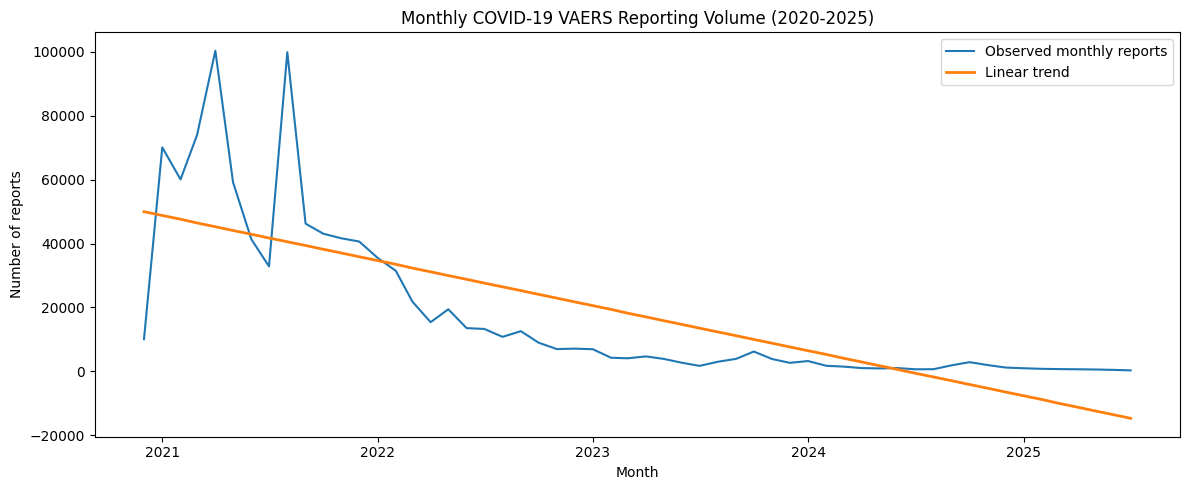

In [ ]:
# ============================================================
# LINEAR REGRESSION: MONTHLY REPORTING VOLUME OVER TIME
# ============================================================

# Model 1: Monthly reporting volume ~ time
X_volume = sm.add_constant(monthly_summary["MONTH_INDEX"])
y_volume = monthly_summary["MONTHLY_REPORTS"]

volume_model = sm.OLS(y_volume, X_volume).fit(cov_type="HC3")

print("MONTHLY REPORTING VOLUME MODEL")
print(volume_model.summary())

# Save model coefficients
volume_results = pd.DataFrame({
    "term": volume_model.params.index,
    "coefficient": volume_model.params.values,
    "p_value": volume_model.pvalues.values,
    "conf_low": volume_model.conf_int()[0].values,
    "conf_high": volume_model.conf_int()[1].values
})
volume_results.to_csv(f"{OUTDIR}/monthly_volume_regression_results.csv", index=False)

# Plot monthly volume with fitted regression line
monthly_summary["VOLUME_PRED"] = volume_model.predict(X_volume)

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["YEAR_MONTH_DATE"], monthly_summary["MONTHLY_REPORTS"], label="Observed monthly reports")
plt.plot(monthly_summary["YEAR_MONTH_DATE"], monthly_summary["VOLUME_PRED"], label="Linear trend", linewidth=2)
plt.title("Monthly COVID-19 VAERS Reporting Volume (2020-2025)")
plt.xlabel("Month")
plt.ylabel("Number of reports")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Severity Proportion Trend

Fit a second linear regression to evaluate whether the monthly proportion of serious reports changed over time, independent of overall volume. 

Model: **`SEVERE_PROPORTION ~ MONTH_INDEX`**

Coefficients, p-values, and confidence intervals are saved to `Outputs/monthly_severe_proportion_regression_results.csv`. The observed series and fitted trend are plotted together.

MONTHLY SEVERE PROPORTION MODEL
                            OLS Regression Results                            
Dep. Variable:      SEVERE_PROPORTION   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     18.65
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           6.77e-05
Time:                        13:36:21   Log-Likelihood:                 45.587
No. Observations:                  56   AIC:                            -87.17
Df Residuals:                      54   BIC:                            -83.12
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.

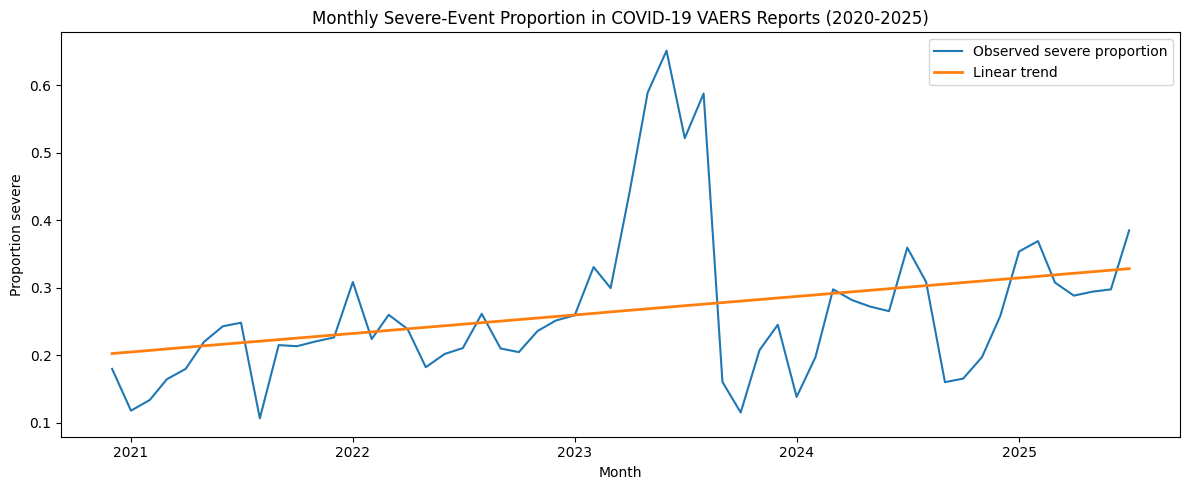

In [ ]:
# ============================================================
# LINEAR REGRESSION: MONTHLY SEVERE-EVENT PROPORTION OVER TIME
# ============================================================

# Model 2: Monthly severe proportion ~ time
X_severe = sm.add_constant(monthly_summary["MONTH_INDEX"])
y_severe = monthly_summary["SEVERE_PROPORTION"]

severe_model = sm.OLS(y_severe, X_severe).fit(cov_type="HC3")

print("MONTHLY SEVERE PROPORTION MODEL")
print(severe_model.summary())

# Save model coefficients
severe_results = pd.DataFrame({
    "term": severe_model.params.index,
    "coefficient": severe_model.params.values,
    "p_value": severe_model.pvalues.values,
    "conf_low": severe_model.conf_int()[0].values,
    "conf_high": severe_model.conf_int()[1].values
})
severe_results.to_csv(f"{OUTDIR}/monthly_severe_proportion_regression_results.csv", index=False)

# Plot monthly severe-event proportion with fitted regression line
monthly_summary["SEVERE_PROP_PRED"] = severe_model.predict(X_severe)

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["YEAR_MONTH_DATE"], monthly_summary["SEVERE_PROPORTION"], label="Observed severe proportion")
plt.plot(monthly_summary["YEAR_MONTH_DATE"], monthly_summary["SEVERE_PROP_PRED"], label="Linear trend", linewidth=2)
plt.title("Monthly Severe-Event Proportion in COVID-19 VAERS Reports (2020-2025)")
plt.xlabel("Month")
plt.ylabel("Proportion severe")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Cluster Prevalence Over Time

For each calendar month, compute what share of that month's clustered reports belonged to each narrative cluster. This shows whether the mix of adverse-event phenotypes shifted across phases of the COVID-19 vaccine rollout.

**Steps:**
1. Filter to rows that received a cluster label (i.e. had ≥ 3 tokens after cleaning)
2. Count reports per `(YEAR_MONTH_DATE, CLUSTER)` combination
3. Divide by the total clustered reports in that month to obtain the monthly proportion for each cluster
4. Save `Outputs/monthly_cluster_proportions.csv`

In [10]:
# ============================================================
# MONTHLY CLUSTER PREVALENCE OVER TIME
# ============================================================

# Make sure df_clean has CLUSTER column
if "CLUSTER" not in df_clean.columns:
    print("CLUSTER column not found in df_clean")
else:
    # Start fresh from df_clean
    df_ts = df_clean.copy()
    
    # Ensure RECVDATE is datetime
    df_ts["RECVDATE"] = pd.to_datetime(df_ts["RECVDATE"], errors="coerce")
    
    # Create YEAR_MONTH_DATE BEFORE filtering
    df_ts["YEAR_MONTH_DATE"] = df_ts["RECVDATE"].dt.to_period("M").dt.to_timestamp()
    
    # Now filter to rows with cluster labels
    df_cluster_ts = df_ts[df_ts["CLUSTER"].notna()].copy()
    df_cluster_ts["CLUSTER"] = df_cluster_ts["CLUSTER"].astype(int)
    
    print("Rows with cluster labels:", df_cluster_ts.shape[0])
    print("Unique clusters:", sorted(df_cluster_ts["CLUSTER"].unique()))
    print("Date range:", df_cluster_ts["YEAR_MONTH_DATE"].min(), "to", df_cluster_ts["YEAR_MONTH_DATE"].max())
    
    # Monthly counts by cluster
    cluster_month_counts = (
        df_cluster_ts.groupby(["YEAR_MONTH_DATE", "CLUSTER"])
        .size()
        .reset_index(name="N_CLUSTER_MONTH")
    )
    
    # Total clustered reports per month
    cluster_month_totals = (
        df_cluster_ts.groupby("YEAR_MONTH_DATE")
        .size()
        .reset_index(name="N_TOTAL_MONTH")
    )
    
    # Merge totals and compute proportions
    cluster_month_props = cluster_month_counts.merge(
        cluster_month_totals,
        on="YEAR_MONTH_DATE",
        how="left"
    )
    
    cluster_month_props["CLUSTER_PROPORTION"] = (
        cluster_month_props["N_CLUSTER_MONTH"] / cluster_month_props["N_TOTAL_MONTH"]
    )
    
    # Save
    cluster_month_props.to_csv(f"{OUTDIR}/monthly_cluster_proportions.csv", index=False)
    
    print("\nCluster-month proportions:")
    print(cluster_month_props.head(10))

Rows with cluster labels: 955349
Unique clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Date range: 2020-12-01 00:00:00 to 2025-07-01 00:00:00

Cluster-month proportions:
  YEAR_MONTH_DATE  CLUSTER  N_CLUSTER_MONTH  N_TOTAL_MONTH  CLUSTER_PROPORTION
0      2020-12-01        0             1471          10087            0.145831
1      2020-12-01        1                8          10087            0.000793
2      2020-12-01        2             1088          10087            0.107862
3      2020-12-01        3             1802          10087            0.178646
4      2020-12-01        4              962          10087            0.095370
5      2020-12-01        5               79          10087            0.007832
6      2020-12-01        6              280          10087            0.027759
7      2020-12-01        7        

## 7. Plot Cluster Prevalence

Line plot showing each cluster's monthly share of reports from January 2020 through March 2025. Each of the 8 clusters is rendered as a separate line, with the legend placed outside the axes to prevent overlap.

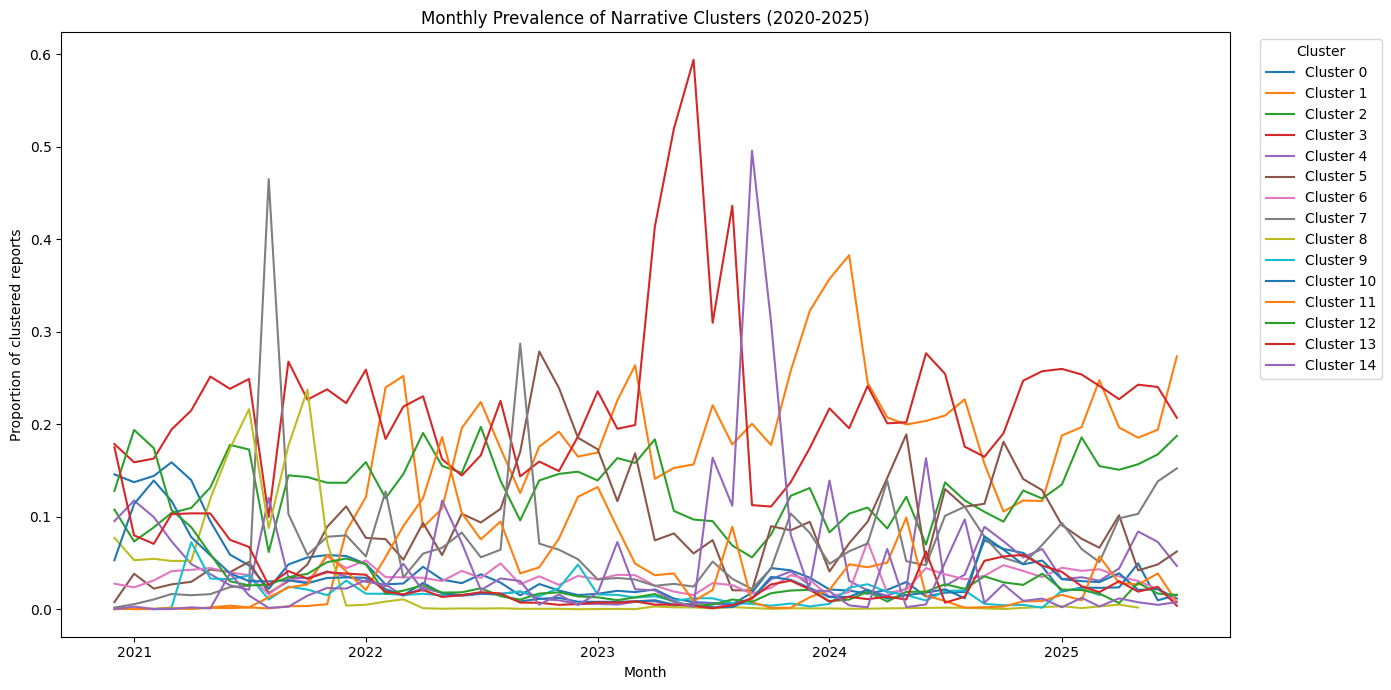

In [11]:
# ============================================================
# PLOT CLUSTER PREVALENCE OVER TIME
# ============================================================

plt.figure(figsize=(14, 7))

for cluster_id in sorted(cluster_month_props["CLUSTER"].unique()):
    cluster_subset = cluster_month_props[cluster_month_props["CLUSTER"] == cluster_id]
    plt.plot(
        cluster_subset["YEAR_MONTH_DATE"],
        cluster_subset["CLUSTER_PROPORTION"],
        label=f"Cluster {cluster_id}"
    )

plt.title("Monthly Prevalence of Narrative Clusters (2020-2025)")
plt.xlabel("Month")
plt.ylabel("Proportion of clustered reports")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Cluster Trend Regressions

For each of the 8 narrative clusters, fit an individual linear regression.

Results saved to `Outputs/cluster_trend_regression_results.csv`.

In [12]:
# ============================================================
# LINEAR REGRESSION FOR EACH CLUSTER'S MONTHLY PREVALENCE
# ============================================================

cluster_trend_results = []

for cluster_id in sorted(cluster_month_props["CLUSTER"].unique()):
    cluster_subset = (
        cluster_month_props[cluster_month_props["CLUSTER"] == cluster_id]
        .sort_values("YEAR_MONTH_DATE")
        .reset_index(drop=True)
    )

    cluster_subset["MONTH_INDEX"] = np.arange(len(cluster_subset))

    X_cluster = sm.add_constant(cluster_subset["MONTH_INDEX"])
    y_cluster = cluster_subset["CLUSTER_PROPORTION"]

    model = sm.OLS(y_cluster, X_cluster).fit(cov_type="HC3")

    cluster_trend_results.append({
        "CLUSTER": cluster_id,
        "INTERCEPT": model.params["const"],
        "SLOPE": model.params["MONTH_INDEX"],
        "P_VALUE": model.pvalues["MONTH_INDEX"],
        "R_SQUARED": model.rsquared
    })

cluster_trend_results_df = pd.DataFrame(cluster_trend_results).sort_values("P_VALUE")
print(cluster_trend_results_df)

cluster_trend_results_df.to_csv(f"{OUTDIR}/cluster_trend_regression_results.csv", index=False)

    CLUSTER  INTERCEPT     SLOPE       P_VALUE  R_SQUARED
1         1   0.042927  0.004055  6.479190e-12   0.449854
8         8   0.089862 -0.002572  4.138535e-06   0.346447
0         0   0.077241 -0.001285  1.976863e-04   0.311283
12       12   0.066653 -0.001256  1.216514e-03   0.296427
13       13   0.057530 -0.000927  4.620427e-03   0.206849
5         5   0.064943  0.000911  1.619836e-02   0.068326
3         3   0.206506  0.000718  3.887124e-02   0.017496
10       10   0.047142 -0.000609  3.994388e-02   0.121312
9         9   0.024390 -0.000302  6.065115e-02   0.122725
14       14   0.028448  0.000414  2.907441e-01   0.006707
6         6   0.035772 -0.000079  4.233257e-01   0.012141
7         7   0.058829  0.000477  4.696443e-01   0.012122
11       11   0.044683 -0.000180  5.637525e-01   0.004775
2         2   0.126217  0.000082  7.833034e-01   0.001468
4         4   0.038708  0.000044  8.946556e-01   0.000389


## 9. Annotated Timeline Plots

Re-plots monthly report volume with vertical dashed lines marking the five key phases of the U.S. COVID-19 vaccine programme:

| Phase marker | Date |
|---|---|
| Initial rollout begins | December 2020 |
| Expanded eligibility (all adults) | March 2021 |
| Booster authorisation period | September 2021 |
| Omicron wave peak | January 2022 |
| Post-rollout stabilisation | January 2023 |

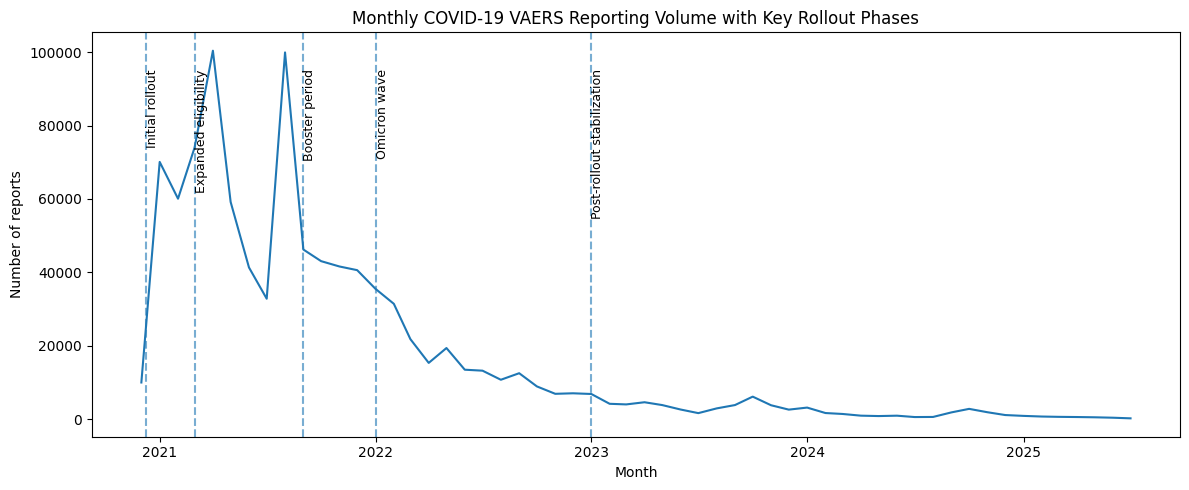

In [ ]:
# ============================================================
# ANNOTATED PLOTS FOR KEY ROLLOUT PHASES
# ============================================================

# You can customize these dates depending on what phases
# you want to highlight in your report.
rollout_dates = [
    ("2020-12-08", "Initial rollout"),
    ("2021-03-01", "Expanded eligibility"),
    ("2021-09-01", "Booster period"),
    ("2022-01-01", "Omicron wave"),
    ("2023-01-01", "Post-rollout stabilization")
]

# Monthly volume plot with annotations
plt.figure(figsize=(12, 5))
plt.plot(monthly_summary["YEAR_MONTH_DATE"], monthly_summary["MONTHLY_REPORTS"], label="Monthly reports")

for date_str, label in rollout_dates:
    date_val = pd.to_datetime(date_str)
    plt.axvline(date_val, linestyle="--", alpha=0.6)
    plt.text(date_val, monthly_summary["MONTHLY_REPORTS"].max()*0.95, label,
             rotation=90, verticalalignment="top", fontsize=9)

plt.title("Monthly COVID-19 VAERS Reporting Volume with Key Rollout Phases")
plt.xlabel("Month")
plt.ylabel("Number of reports")
plt.tight_layout()
plt.show()